 
# In vitro reconstitution of a candidate mitochondrial permeability transition system
## Proof-of-concept notebook 
This notebook generates a **synthetic, literature-benchmarked proof-of-concept dataset** for a candidate **mPTP-like reconstitution system** built conceptually around **ANT**, **F1FO-ATP synthase**, and **Cyclophilin D**, with optional **PiC** modulation. It is intended for proposal development, hypothesis generation, and experimental prioritization.

**Literature anchors used to shape the simulation**
- Bernardi et al., 2023, Cell Death & Differentiation. https://doi.org/10.1038/s41418-023-01187-0  
- Endlicher et al., 2023, Cells. https://doi.org/10.3390/cells12091273  
- Ong et al., 2015, Journal of Molecular and Cellular Cardiology. https://doi.org/10.1016/j.yjmcc.2014.11.005  
- Javadov, 2015, Frontiers in Physiology. https://doi.org/10.3389/fphys.2015.00083  
- Neginskaya et al., 2022, iScience. https://doi.org/10.1016/j.isci.2022.105447  
- Tommasin et al., 2025, The Journal of Physiology. https://doi.org/10.1113/JP287147  
- Rasola & Bernardi, 2014, Cell Calcium. https://doi.org/10.1016/j.ceca.2014.10.003  
- Guo, 2021, Biochemical Pharmacology. https://doi.org/10.1016/j.bcp.2021.114537

The notebook saves all figures and tables to:

`mptp_reconstitution_package/outputs`


In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import roc_auc_score, average_precision_score, r2_score, mean_squared_error, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

BASE_OUT = Path("mptp_reconstitution_package")
OUTDIR = BASE_OUT / "outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)


## 1. Simulate disease states, reconstitution contexts, and pore-relevant variables

In [7]:

states = {
    "Cardiac_Control": {
        "delta_psi_mV": (165, 8, 140, 185),
        "matrix_ca_au": (0.28, 0.08, 0.08, 0.60),
        "mtROS_au": (0.22, 0.08, 0.03, 0.55),
        "pH_au": (7.20, 0.05, 6.95, 7.35),
        "adp_atp_ratio": (0.45, 0.10, 0.15, 0.85),
        "cardiolipin_index": (1.00, 0.06, 0.82, 1.15),
        "CypD_activity_au": (0.52, 0.10, 0.20, 0.85),
        "ANT_function_au": (0.88, 0.08, 0.55, 1.10),
        "ATPsynthase_pore_propensity_au": (0.50, 0.10, 0.20, 0.85),
        "PiC_modulation_au": (0.45, 0.08, 0.20, 0.75),
        "stress_offset": 0.00,
    },
    "Cardiac_Ischemia_Reperfusion": {
        "delta_psi_mV": (118, 18, 65, 165),
        "matrix_ca_au": (0.86, 0.12, 0.45, 1.25),
        "mtROS_au": (0.88, 0.12, 0.45, 1.30),
        "pH_au": (6.72, 0.10, 6.40, 7.05),
        "adp_atp_ratio": (1.20, 0.18, 0.60, 1.70),
        "cardiolipin_index": (0.88, 0.07, 0.65, 1.05),
        "CypD_activity_au": (0.82, 0.10, 0.45, 1.10),
        "ANT_function_au": (0.82, 0.10, 0.45, 1.05),
        "ATPsynthase_pore_propensity_au": (0.84, 0.10, 0.45, 1.15),
        "PiC_modulation_au": (0.60, 0.10, 0.25, 0.95),
        "stress_offset": 0.55,
    },
    "Cancer_Therapy_Naive": {
        "delta_psi_mV": (150, 11, 120, 178),
        "matrix_ca_au": (0.43, 0.10, 0.12, 0.72),
        "mtROS_au": (0.40, 0.10, 0.12, 0.72),
        "pH_au": (6.98, 0.07, 6.75, 7.15),
        "adp_atp_ratio": (0.70, 0.13, 0.30, 1.05),
        "cardiolipin_index": (0.95, 0.07, 0.75, 1.12),
        "CypD_activity_au": (0.60, 0.10, 0.20, 0.90),
        "ANT_function_au": (0.74, 0.10, 0.35, 1.00),
        "ATPsynthase_pore_propensity_au": (0.66, 0.10, 0.30, 0.98),
        "PiC_modulation_au": (0.52, 0.08, 0.20, 0.82),
        "stress_offset": 0.18,
    },
    "Cancer_Stress_Adapted": {
        "delta_psi_mV": (147, 13, 110, 180),
        "matrix_ca_au": (0.49, 0.11, 0.12, 0.85),
        "mtROS_au": (0.55, 0.12, 0.20, 0.92),
        "pH_au": (6.90, 0.07, 6.65, 7.10),
        "adp_atp_ratio": (0.58, 0.11, 0.25, 0.95),
        "cardiolipin_index": (0.97, 0.08, 0.74, 1.15),
        "CypD_activity_au": (0.46, 0.09, 0.12, 0.78),
        "ANT_function_au": (0.70, 0.09, 0.30, 0.98),
        "ATPsynthase_pore_propensity_au": (0.56, 0.10, 0.18, 0.88),
        "PiC_modulation_au": (0.48, 0.08, 0.18, 0.78),
        "stress_offset": -0.18,
    },
}
perturbations = {
    "WT": {"CypD": 0.0, "ANT": 0.0, "ATPsyn": 0.0},
    "CypD_low": {"CypD": -0.22, "ANT": 0.0, "ATPsyn": 0.0},
    "ANT_low": {"CypD": 0.0, "ANT": -0.25, "ATPsyn": 0.0},
    "ATPsyn_low": {"CypD": 0.0, "ANT": 0.0, "ATPsyn": -0.22},
    "ANT_ATPsyn_low": {"CypD": 0.0, "ANT": -0.23, "ATPsyn": -0.20},
}
state_order = ["Cardiac_Control","Cardiac_Ischemia_Reperfusion","Cancer_Therapy_Naive","Cancer_Stress_Adapted"]
pert_order = ["WT","CypD_low","ANT_low","ATPsyn_low","ANT_ATPsyn_low"]

def clipped_normal(mean, sd, low, high, n):
    return np.clip(np.random.normal(mean, sd, n), low, high)

rows = []
n_per_combo = 120
for state_name, cfg in states.items():
    for perturb_name, p in perturbations.items():
        delta_psi = clipped_normal(*cfg["delta_psi_mV"], n_per_combo)
        matrix_ca = clipped_normal(*cfg["matrix_ca_au"], n_per_combo)
        mtros = clipped_normal(*cfg["mtROS_au"], n_per_combo)
        ph = clipped_normal(*cfg["pH_au"], n_per_combo)
        adp_atp = clipped_normal(*cfg["adp_atp_ratio"], n_per_combo)
        cardiolipin = clipped_normal(*cfg["cardiolipin_index"], n_per_combo)
        cypd = np.clip(clipped_normal(*cfg["CypD_activity_au"], n_per_combo) + p["CypD"], 0.05, 1.20)
        ant = np.clip(clipped_normal(*cfg["ANT_function_au"], n_per_combo) + p["ANT"], 0.05, 1.20)
        atpsyn = np.clip(clipped_normal(*cfg["ATPsynthase_pore_propensity_au"], n_per_combo) + p["ATPsyn"], 0.05, 1.20)
        pic = clipped_normal(*cfg["PiC_modulation_au"], n_per_combo)

        delta_psi_vuln = np.clip((170 - delta_psi)/100.0, 0, 1.2)
        acidosis_vuln = np.clip((7.2 - ph)/0.8, 0, 1.2)

        transient = (
            0.30*matrix_ca + 0.22*mtros + 0.14*cypd + 0.12*ant + 0.12*atpsyn +
            0.10*delta_psi_vuln + 0.08*acidosis_vuln + np.random.normal(0, 0.05, n_per_combo)
        )
        transient = np.clip(transient, 0, None)

        lin = (
            1.25*matrix_ca + 0.92*mtros + 0.95*cypd + 1.10*ant + 0.98*atpsyn +
            0.70*delta_psi_vuln + 0.38*acidosis_vuln + 0.18*pic + 0.20*adp_atp + cfg["stress_offset"]
        )
        if perturb_name == "ANT_ATPsyn_low":
            lin -= 0.40
        elif perturb_name in ["ANT_low", "ATPsyn_low", "CypD_low"]:
            lin -= 0.18
        lin += np.random.normal(0, 0.12, n_per_combo)

        sustained_prob = 1/(1+np.exp(-(lin-2.1)))
        sustained_prob = np.clip(sustained_prob, 0.001, 0.999)
        sustained_open = np.random.binomial(1, sustained_prob, n_per_combo)

        crc_au = np.clip(
            1.40 - 0.72*matrix_ca - 0.30*mtros - 0.25*sustained_prob + 0.20*(1-delta_psi_vuln) + 0.10*cardiolipin +
            np.random.normal(0,0.06,n_per_combo), 0.12, 1.55
        )
        threshold_ca = np.clip(
            240 - 110*matrix_ca - 38*mtros - 26*sustained_prob + 18*cardiolipin + 12*(1-acidosis_vuln) +
            np.random.normal(0,9,n_per_combo), 25, 320
        )
        leakage_auc = np.clip(
            0.30 + 0.72*sustained_prob + 0.26*transient + 0.16*mtros - 0.08*cardiolipin +
            np.random.normal(0,0.05,n_per_combo), 0.05, 1.45
        )
        conductance = np.clip(
            0.15 + 0.66*sustained_prob + 0.18*cypd + 0.20*ant + 0.18*atpsyn + 0.12*matrix_ca +
            np.random.normal(0,0.05,n_per_combo), 0.02, 1.60
        )
        t_open = np.clip(
            320 - 150*sustained_prob - 38*mtros - 52*matrix_ca + 40*cardiolipin + 15*(1-acidosis_vuln) +
            np.random.normal(0,12,n_per_combo), 8, 360
        )
        atp = np.clip(
            1.00 - 0.38*delta_psi_vuln - 0.24*sustained_prob - 0.14*mtros + 0.08*cardiolipin - 0.06*adp_atp +
            np.random.normal(0,0.04,n_per_combo), 0.05, 1.20
        )
        mtdna = np.clip(
            0.16 + 1.05*sustained_prob + 0.20*transient + 0.26*mtros + np.random.normal(0,0.06,n_per_combo),
            0.03, 2.20
        )
        viability = np.clip(
            1.02 - 0.44*sustained_prob - 0.14*transient - 0.12*mtros + 0.15*(1-delta_psi_vuln) + 0.05*cardiolipin +
            np.random.normal(0,0.04,n_per_combo), 0.02, 1.00
        )

        for i in range(n_per_combo):
            rows.append({
                "state": state_name, "perturbation": perturb_name,
                "delta_psi_mV": float(delta_psi[i]), "matrix_ca_au": float(matrix_ca[i]),
                "mtROS_au": float(mtros[i]), "pH_au": float(ph[i]), "adp_atp_ratio": float(adp_atp[i]),
                "cardiolipin_index": float(cardiolipin[i]), "CypD_activity_au": float(cypd[i]),
                "ANT_function_au": float(ant[i]), "ATPsynthase_pore_propensity_au": float(atpsyn[i]),
                "PiC_modulation_au": float(pic[i]), "transient_pore_score": float(transient[i]),
                "sustained_pore_prob": float(sustained_prob[i]), "sustained_pore_open": int(sustained_open[i]),
                "crc_au": float(crc_au[i]), "threshold_ca_uM": float(threshold_ca[i]),
                "leakage_auc": float(leakage_auc[i]), "conductance_au": float(conductance[i]),
                "time_to_sustained_open_s": float(t_open[i]), "ATP_index": float(atp[i]),
                "mtDNA_release_proxy": float(mtdna[i]), "viability_proxy": float(viability[i]),
            })

df = pd.DataFrame(rows)
df.to_csv(OUTDIR / "synthetic_mptp_reconstitution_dataset.csv", index=False)
display(df.head())
print("Rows:", len(df))


,state,perturbation,delta_psi_mV,matrix_ca_au,mtROS_au,pH_au,adp_atp_ratio,cardiolipin_index,CypD_activity_au,ANT_function_au,...,sustained_pore_prob,sustained_pore_open,crc_au,threshold_ca_uM,leakage_auc,conductance_au,time_to_sustained_open_s,ATP_index,mtDNA_release_proxy,viability_proxy
0,Cardiac_Control,WT,168.973713,0.343283,0.156598,7.225967,0.437208,1.045419,0.550780,0.876043,...,0.666067,0,1.272646,211.304125,0.793017,0.993777,249.931047,0.875795,1.032234,0.839225
1,Cardiac_Control,WT,163.893886,0.207249,0.210821,7.276637,0.354446,0.944670,0.348983,0.933986,...,0.642299,0,1.277252,233.354067,0.804581,1.042259,233.607419,0.909398,0.929997,0.800911
2,Cardiac_Control,WT,170.181508,0.392224,0.260399,7.194562,0.289355,1.052176,0.385181,0.790182,...,0.623068,1,1.118735,192.559200,0.786741,0.957244,260.859112,0.831256,0.804216,0.845692
3,Cardiac_Control,WT,177.184239,0.167852,0.289260,7.220086,0.470346,1.081338,0.594326,0.910593,...,0.682446,1,1.157555,234.523804,0.821071,0.997642,241.295396,0.795302,1.044141,0.843191
4,Cardiac_Control,WT,163.126773,0.326949,0.123976,7.234507,0.374365,1.024806,0.537087,0.893316,...,0.648865,0,1.252271,224.754624,0.732475,1.016056,257.669320,0.866911,0.974944,0.819364


Rows: 2400


In [9]:

state_summary = df.groupby("state")[[
    "delta_psi_mV","matrix_ca_au","mtROS_au","CypD_activity_au","ANT_function_au",
    "ATPsynthase_pore_propensity_au","crc_au","threshold_ca_uM","leakage_auc",
    "conductance_au","sustained_pore_prob","ATP_index","mtDNA_release_proxy","viability_proxy"
]].agg(["mean","std"]).round(3)
state_summary.to_csv(OUTDIR / "state_summary_statistics.csv")

perturb_summary = df.groupby(["state","perturbation"])[[
    "crc_au","threshold_ca_uM","leakage_auc","conductance_au",
    "sustained_pore_prob","ATP_index","mtDNA_release_proxy","viability_proxy"
]].mean().round(3)
perturb_summary.to_csv(OUTDIR / "state_perturbation_summary.csv")

display(state_summary.head())


delta_psi_mV         matrix_ca_au         \
                                     mean     std         mean    std   
state                                                                   
Cancer_Stress_Adapted             147.284  12.690        0.497  0.113   
Cancer_Therapy_Naive              149.759  11.235        0.426  0.101   
Cardiac_Control                   164.743   8.007        0.282  0.079   
Cardiac_Ischemia_Reperfusion      117.562  17.982        0.865  0.122   

                             mtROS_au        CypD_activity_au         \
                                 mean    std             mean    std   
state                                                                  
Cancer_Stress_Adapted           0.547  0.119            0.422  0.127   
Cancer_Therapy_Naive            0.402  0.099            0.556  0.137   
Cardiac_Control                 0.223  0.074            0.475  0.135   
Cardiac_Ischemia_Reperfusion    0.878  0.123            0.776  0.137   

                             ANT_function_au         ... conductance_au  \
                                        mean    std  ...           mean   
state                                                ...                  
Cancer_Stress_Adapted                  0.602  0.155  ...          0.929   
Cancer_Therapy_Naive                   0.646  0.154  ...          1.023   
Cardiac_Control                        0.782  0.151  ...          0.865   
Cardiac_Ischemia_Reperfusion           0.723  0.153  ...          1.315   

                                    sustained_pore_prob        ATP_index  \
                                std                mean    std      mean   
state                                                                      
Cancer_Stress_Adapted         0.105               0.663  0.086     0.721   
Cancer_Therapy_Naive          0.104               0.739  0.076     0.721   
Cardiac_Control               0.114               0.552  0.092     0.865   
Cardiac_Ischemia_Reperfusion  0.072               0.964  0.015     0.443   

                                    mtDNA_release_proxy         \
                                std                mean    std   
state                                                            
Cancer_Stress_Adapted         0.073               1.098  0.128   
Cancer_Therapy_Naive          0.067               1.136  0.117   
Cardiac_Control               0.055               0.867  0.126   
Cardiac_Ischemia_Reperfusion  0.083               1.570  0.074   

                             viability_proxy         
                                        mean    std  
state                                                
Cancer_Stress_Adapted                  0.756  0.068  
Cancer_Therapy_Naive                   0.745  0.065  
Cardiac_Control                        0.891  0.061  
Cardiac_Ischemia_Reperfusion           0.487  0.058  

[4 rows x 28 columns]

/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_5171/2891388373.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=state_order, patch_artist=False, showfliers=True)


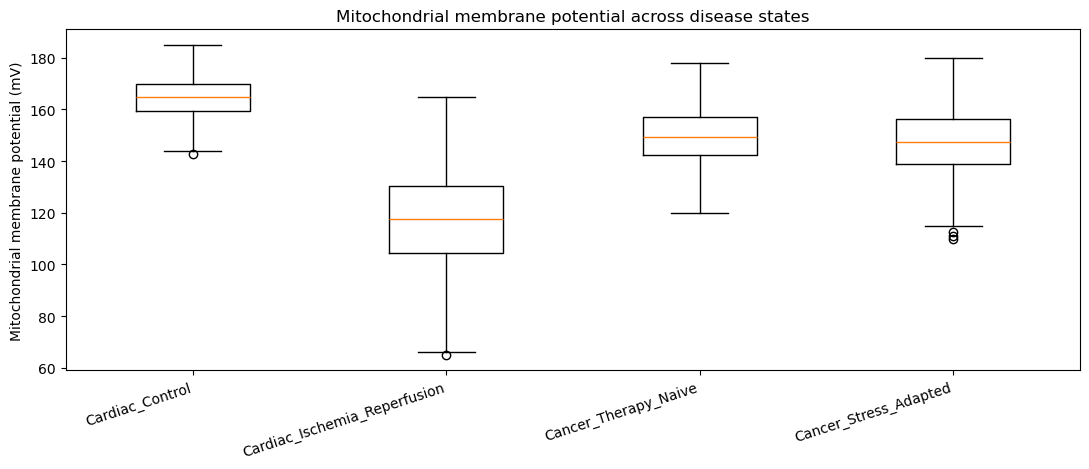

/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_5171/2891388373.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=state_order, patch_artist=False, showfliers=True)


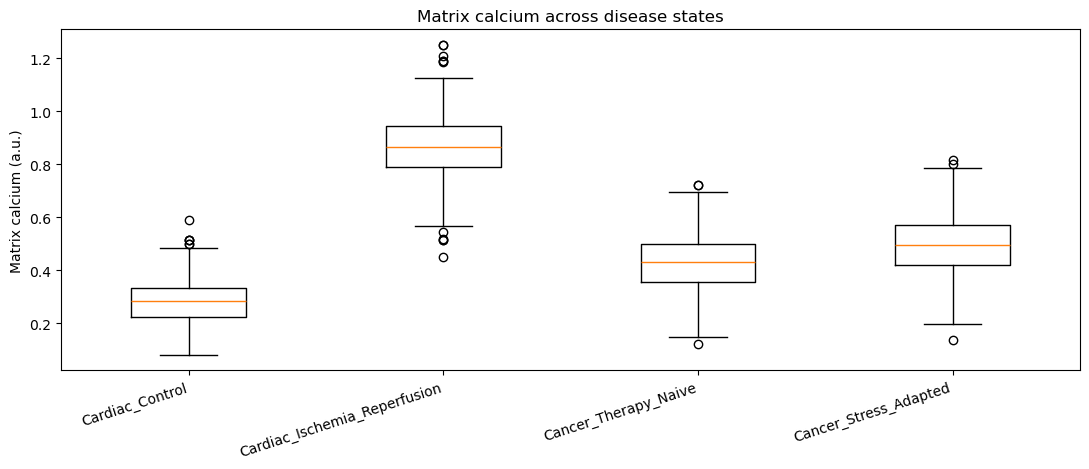

/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_5171/2891388373.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=state_order, patch_artist=False, showfliers=True)


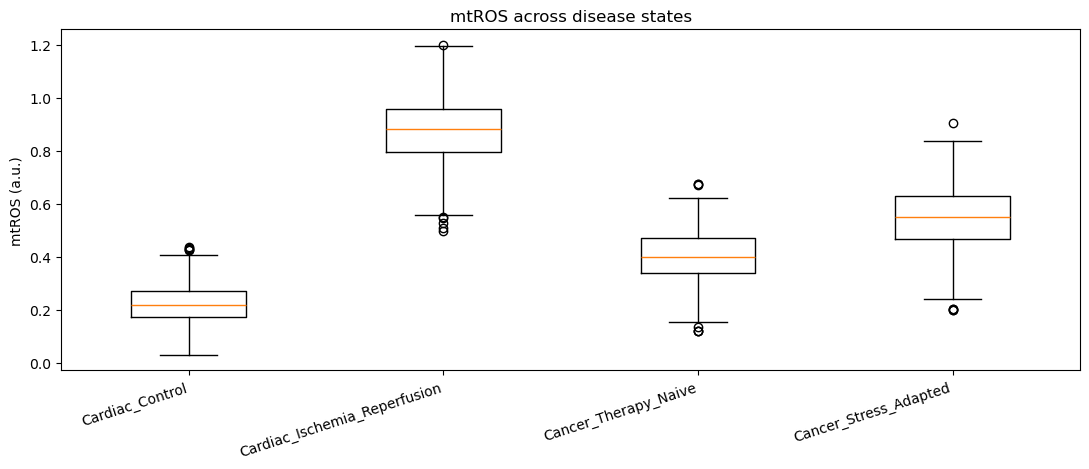

/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_5171/2891388373.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=state_order, patch_artist=False, showfliers=True)


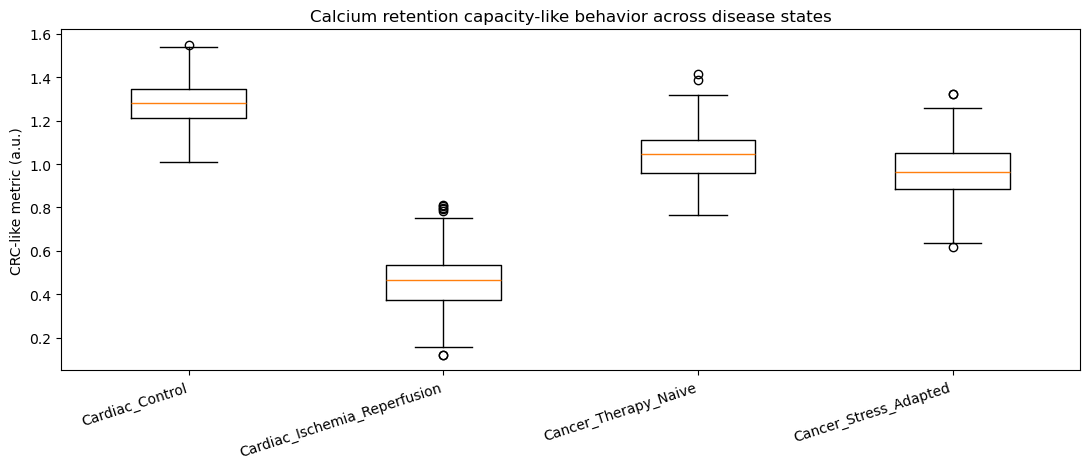

/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_5171/2891388373.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=state_order, patch_artist=False, showfliers=True)


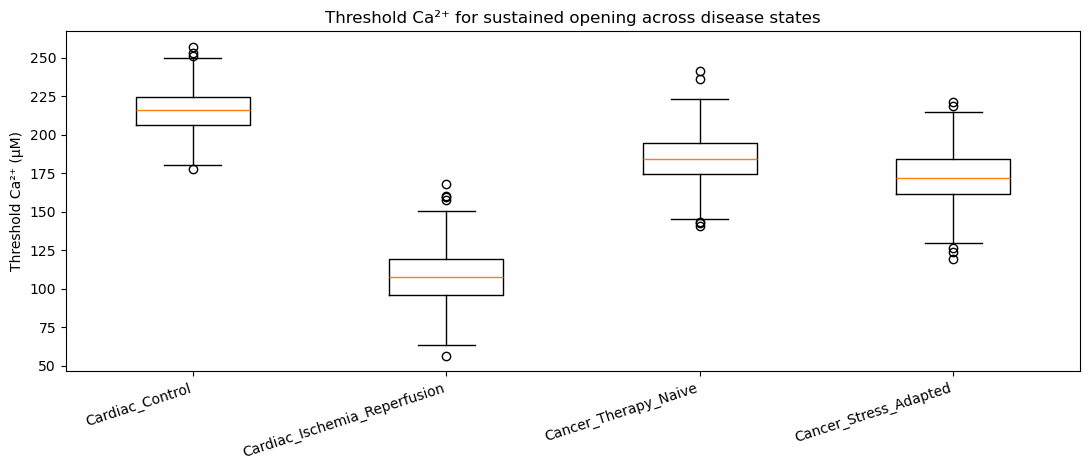

/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_5171/2891388373.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=state_order, patch_artist=False, showfliers=True)


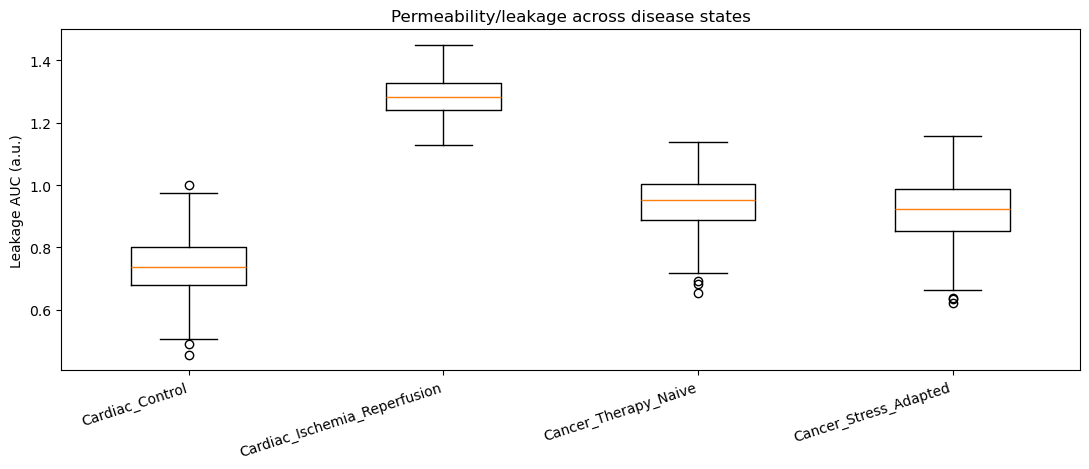

/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_5171/2891388373.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=state_order, patch_artist=False, showfliers=True)


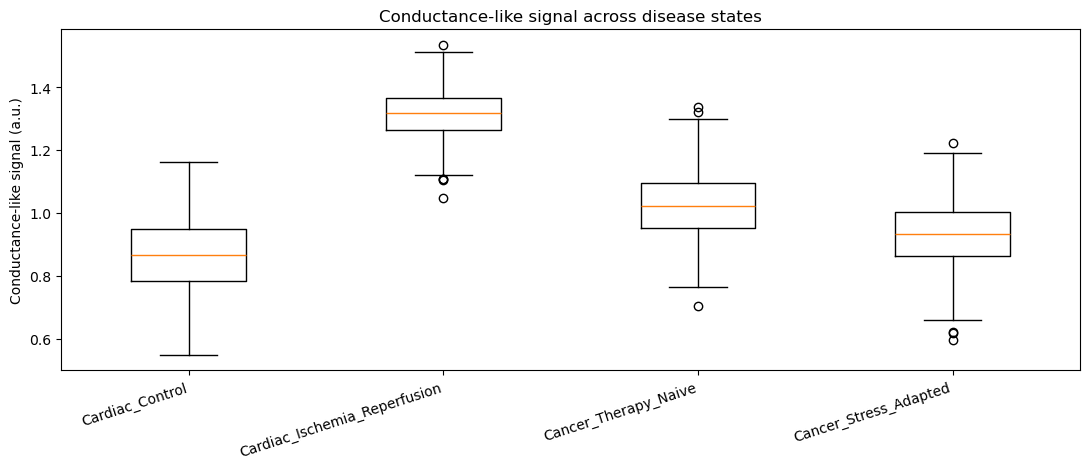

/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_5171/2891388373.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=state_order, patch_artist=False, showfliers=True)


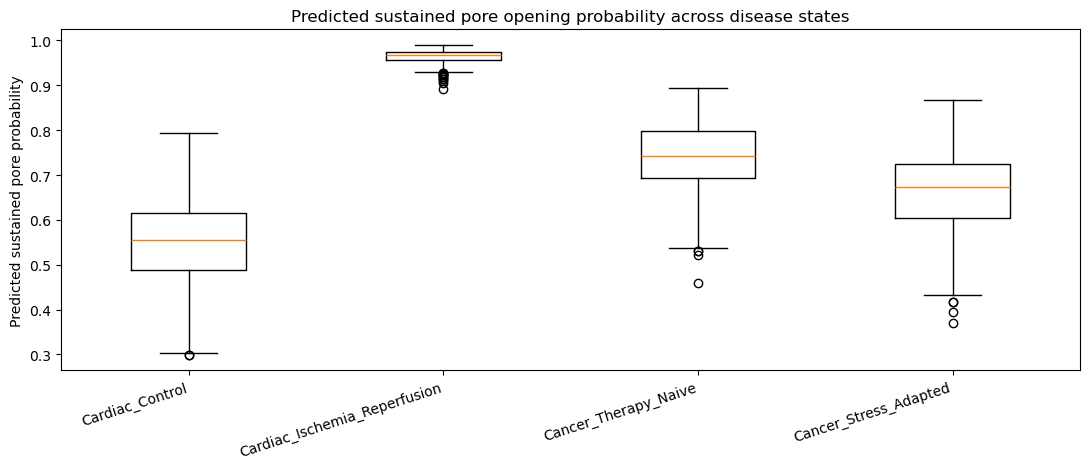

/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_5171/2891388373.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=state_order, patch_artist=False, showfliers=True)


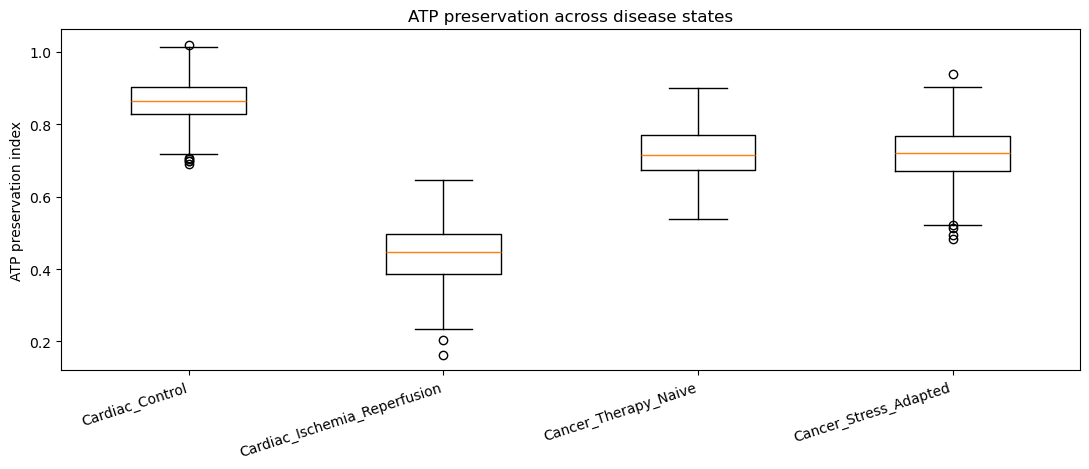

/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_5171/2891388373.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=state_order, patch_artist=False, showfliers=True)


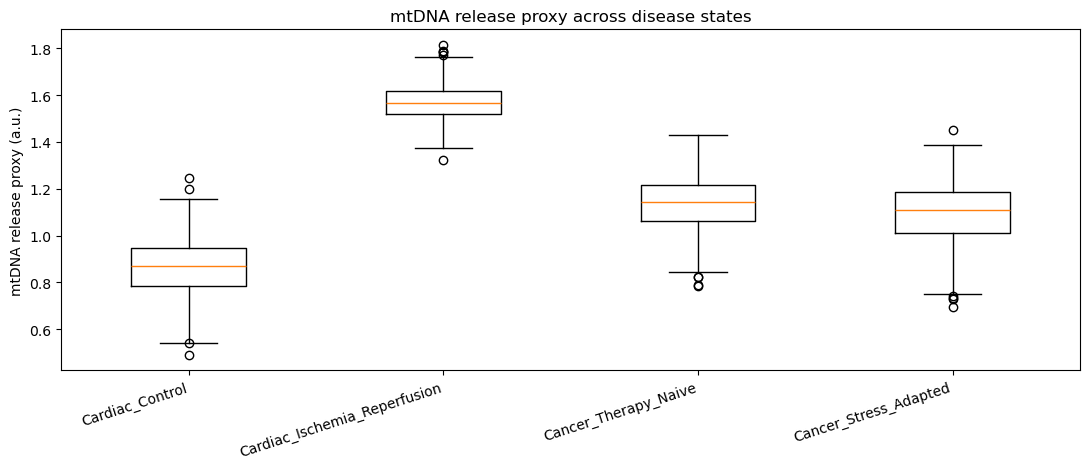

/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_5171/2891388373.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=state_order, patch_artist=False, showfliers=True)


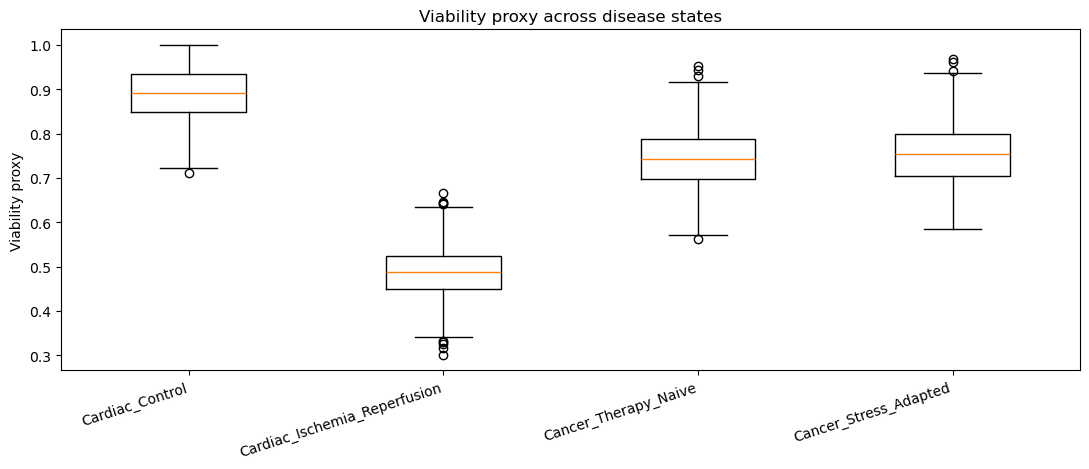

In [11]:

def save_boxplot(ycol, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(11, 4.8))
    data = [df.loc[df["state"] == s, ycol].values for s in state_order]
    ax.boxplot(data, labels=state_order, patch_artist=False, showfliers=True)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=18, ha="right")
    plt.tight_layout()
    fig.savefig(OUTDIR / filename, dpi=220, bbox_inches="tight")
    plt.show()

for metric, ylabel, title, fname in [
    ("delta_psi_mV", "Mitochondrial membrane potential (mV)", "Mitochondrial membrane potential across disease states", "01_delta_psi_by_state.png"),
    ("matrix_ca_au", "Matrix calcium (a.u.)", "Matrix calcium across disease states", "02_matrix_calcium_by_state.png"),
    ("mtROS_au", "mtROS (a.u.)", "mtROS across disease states", "03_mtros_by_state.png"),
    ("crc_au", "CRC-like metric (a.u.)", "Calcium retention capacity-like behavior across disease states", "04_crc_by_state.png"),
    ("threshold_ca_uM", "Threshold Ca²⁺ (µM)", "Threshold Ca²⁺ for sustained opening across disease states", "05_threshold_ca_by_state.png"),
    ("leakage_auc", "Leakage AUC (a.u.)", "Permeability/leakage across disease states", "06_leakage_auc_by_state.png"),
    ("conductance_au", "Conductance-like signal (a.u.)", "Conductance-like signal across disease states", "07_conductance_by_state.png"),
    ("sustained_pore_prob", "Predicted sustained pore probability", "Predicted sustained pore opening probability across disease states", "08_sustained_pore_probability_by_state.png"),
    ("ATP_index", "ATP preservation index", "ATP preservation across disease states", "09_atp_index_by_state.png"),
    ("mtDNA_release_proxy", "mtDNA release proxy (a.u.)", "mtDNA release proxy across disease states", "10_mtdna_release_by_state.png"),
    ("viability_proxy", "Viability proxy", "Viability proxy across disease states", "11_viability_by_state.png"),
]:
    save_boxplot(metric, ylabel, title, fname)


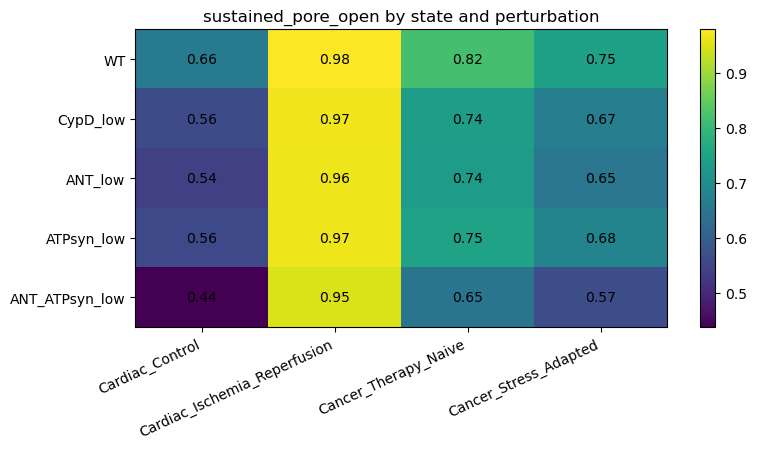

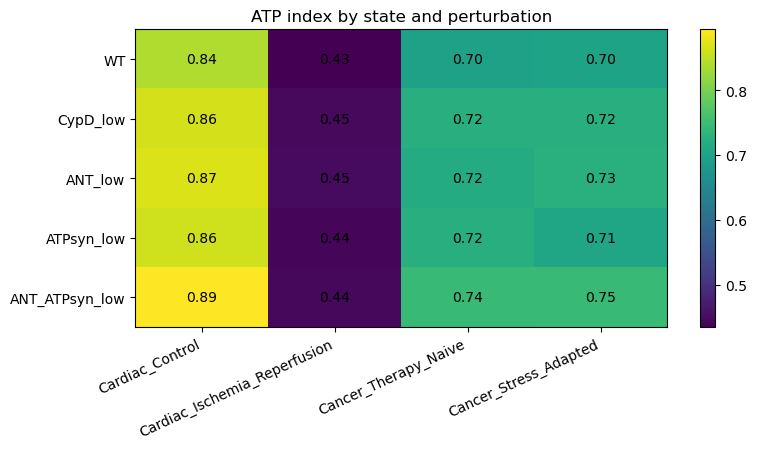

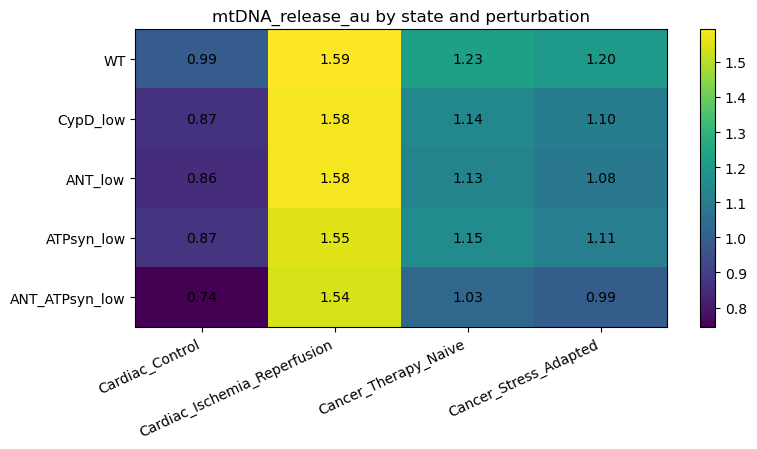

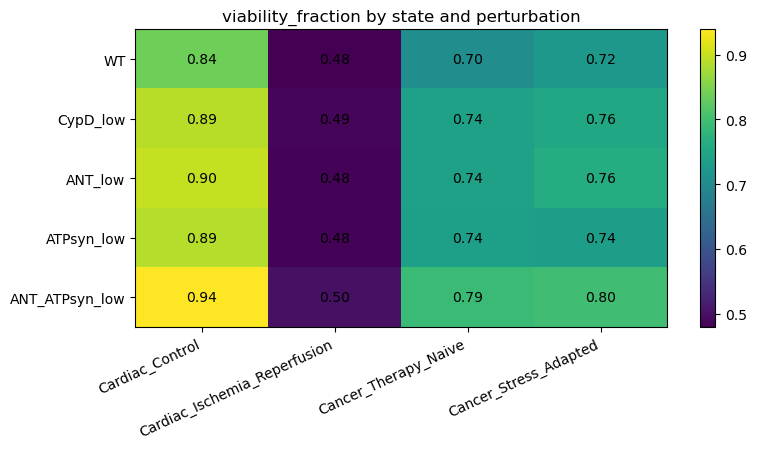

In [13]:

def save_heatmap(metric, title, filename, cmap="viridis"):
    pivot = df.groupby(["perturbation","state"])[metric].mean().reset_index().pivot(index="perturbation", columns="state", values=metric).reindex(index=pert_order, columns=state_order)
    fig, ax = plt.subplots(figsize=(8.2, 4.6))
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=25, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.iloc[i,j]:.2f}", ha="center", va="center", color="black")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    fig.savefig(OUTDIR / filename, dpi=220, bbox_inches="tight")
    plt.show()
    return pivot

p1 = save_heatmap("sustained_pore_prob", "sustained_pore_open by state and perturbation", "heatmap_sustained_pore_open.png")
p2 = save_heatmap("ATP_index", "ATP index by state and perturbation", "heatmap_ATP_index.png")
p3 = save_heatmap("mtDNA_release_proxy", "mtDNA_release_au by state and perturbation", "heatmap_mtDNA_release_au.png")
p4 = save_heatmap("viability_proxy", "viability_fraction by state and perturbation", "heatmap_viability_fraction.png")


## 2. Machine learning classification for sustained pathological opening

ROC-AUC: 0.705
Average precision: 0.867
Confusion matrix:
[[ 20 171]
 [ 14 515]]


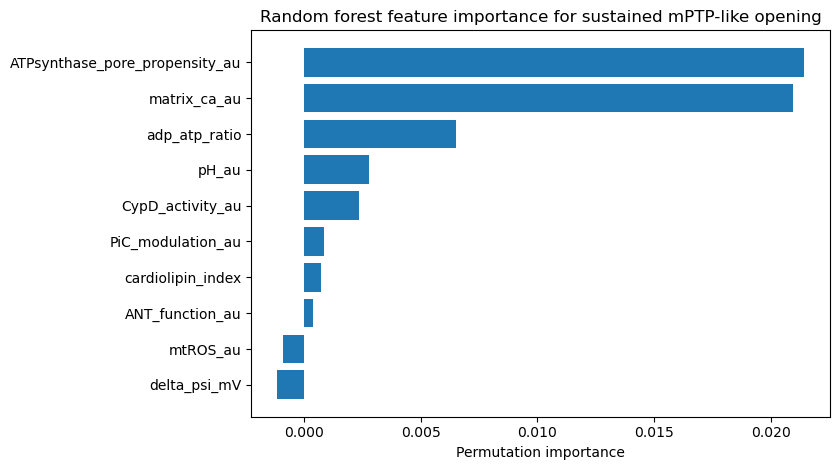

,feature,permutation_importance
0,delta_psi_mV,-0.001132
2,mtROS_au,-0.000875
7,ANT_function_au,0.000373
5,cardiolipin_index,0.000721
9,PiC_modulation_au,0.000849
6,CypD_activity_au,0.002351
3,pH_au,0.002790
4,adp_atp_ratio,0.006534
1,matrix_ca_au,0.020943
8,ATPsynthase_pore_propensity_au,0.021403


In [16]:

feature_cols = [
    "delta_psi_mV","matrix_ca_au","mtROS_au","pH_au","adp_atp_ratio",
    "cardiolipin_index","CypD_activity_au","ANT_function_au",
    "ATPsynthase_pore_propensity_au","PiC_modulation_au"
]
X = df[feature_cols]
y = df["sustained_pore_open"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=500, max_depth=6, min_samples_leaf=8, random_state=42)
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:,1]
pred = clf.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))
print("Average precision:", round(average_precision_score(y_test, proba), 3))
print("Confusion matrix:")
print(confusion_matrix(y_test, pred))

perm = permutation_importance(clf, X_test, y_test, n_repeats=15, random_state=42, scoring="roc_auc")
perm_df = pd.DataFrame({"feature": feature_cols, "permutation_importance": perm.importances_mean}).sort_values("permutation_importance", ascending=True)
perm_df.to_csv(OUTDIR / "random_forest_permutation_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(8.5,4.8))
ax.barh(perm_df["feature"], perm_df["permutation_importance"])
ax.set_title("Random forest feature importance for sustained mPTP-like opening")
ax.set_xlabel("Permutation importance")
plt.tight_layout()
fig.savefig(OUTDIR / "12_feature_importance_sustained_pore.png", dpi=220, bbox_inches="tight")
plt.show()

display(perm_df)


## 3. AI/ML regression for downstream functional outputs

crc_au R2 = 0.955 | RMSE = 0.068
ATP_index R2 = 0.933 | RMSE = 0.043
mtDNA_release_proxy R2 = 0.953 | RMSE = 0.06
viability_proxy R2 = 0.929 | RMSE = 0.042


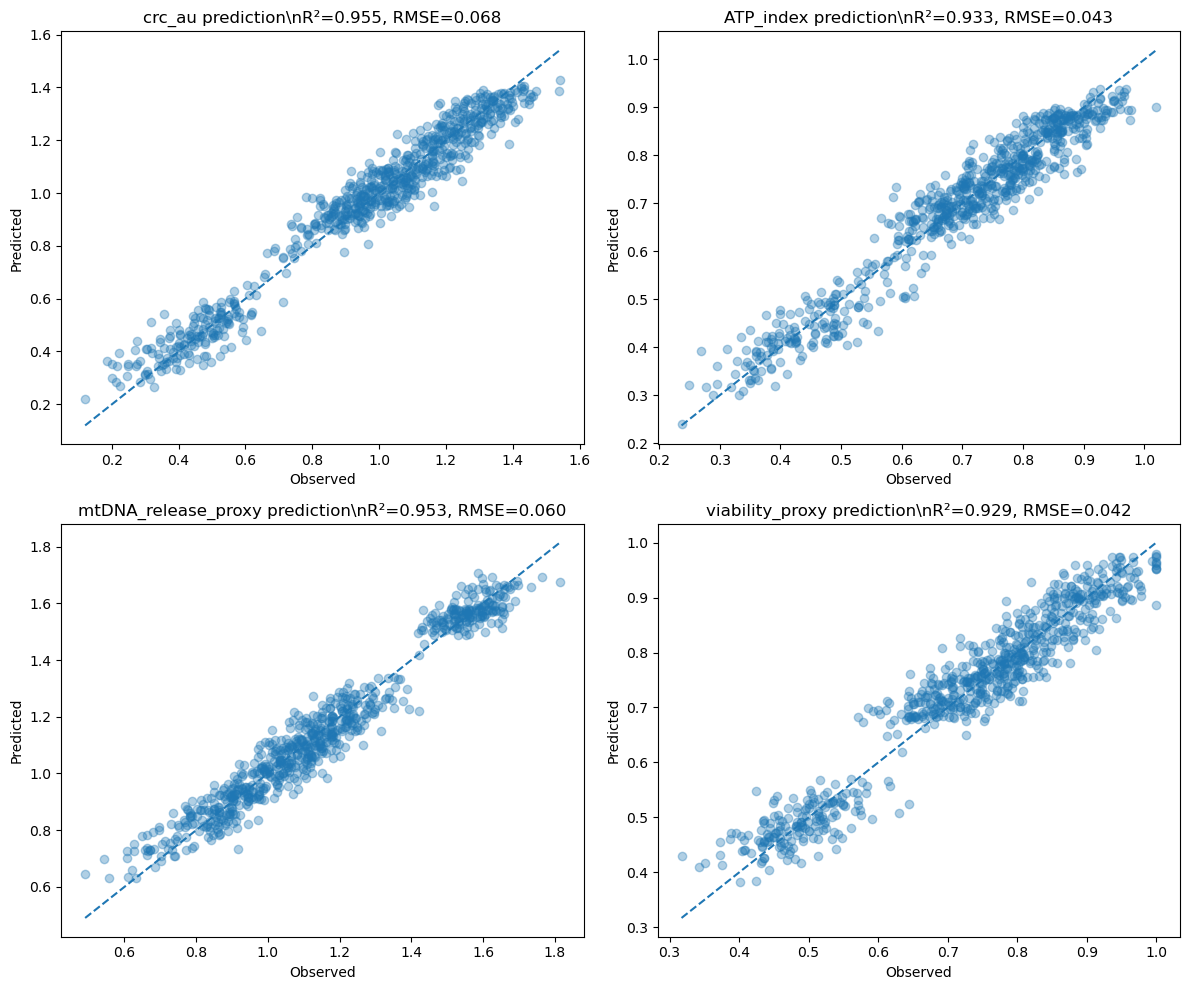

In [19]:

reg_features = feature_cols + ["transient_pore_score", "sustained_pore_prob"]

def run_regression(target):
    X = df[reg_features]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
    reg = RandomForestRegressor(n_estimators=400, max_depth=7, random_state=42)
    reg.fit(X_train, y_train)
    pred = reg.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    rmse = float(np.sqrt(mse))
    return y_test, pred, r2_score(y_test, pred), rmse

targets = ["crc_au","ATP_index","mtDNA_release_proxy","viability_proxy"]
reg_results = {t: run_regression(t) for t in targets}

for t in targets:
    _, _, r2, rmse = reg_results[t]
    print(t, "R2 =", round(r2,3), "| RMSE =", round(rmse,3))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, t in zip(axes.ravel(), targets):
    y_obs, y_pred, r2, rmse = reg_results[t]
    ax.scatter(y_obs, y_pred, alpha=0.35)
    lo = min(float(np.min(y_obs)), float(np.min(y_pred)))
    hi = max(float(np.max(y_obs)), float(np.max(y_pred)))
    ax.plot([lo, hi], [lo, hi], linestyle="--")
    ax.set_title(f"{t} prediction\\nR²={r2:.3f}, RMSE={rmse:.3f}")
    ax.set_xlabel("Observed")
    ax.set_ylabel("Predicted")
plt.tight_layout()
fig.savefig(OUTDIR / "13_regression_prediction_plots.png", dpi=220, bbox_inches="tight")
plt.show()


## 4. PCA structure of disease-state phenotypes

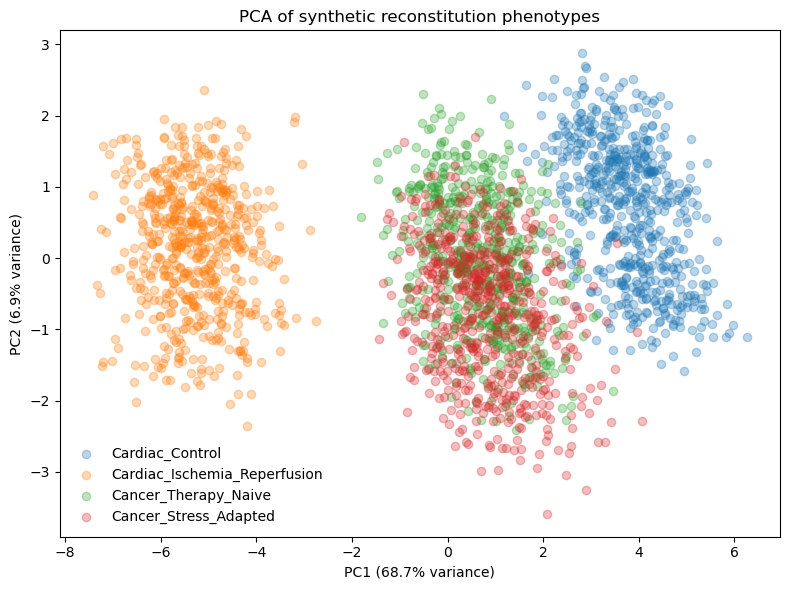

In [22]:

pca_cols = [
    "delta_psi_mV","matrix_ca_au","mtROS_au","pH_au","adp_atp_ratio","cardiolipin_index",
    "CypD_activity_au","ANT_function_au","ATPsynthase_pore_propensity_au","PiC_modulation_au",
    "crc_au","threshold_ca_uM","leakage_auc","conductance_au","ATP_index","mtDNA_release_proxy","viability_proxy"
]
scaled = StandardScaler().fit_transform(df[pca_cols])
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(scaled)
pca_df = pd.DataFrame({"PC1": pcs[:,0], "PC2": pcs[:,1], "state": df["state"]})

fig, ax = plt.subplots(figsize=(8,6))
for s in state_order:
    sub = pca_df[pca_df["state"] == s]
    ax.scatter(sub["PC1"], sub["PC2"], alpha=0.30, label=s)
ax.set_title("PCA of synthetic reconstitution phenotypes")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(OUTDIR / "14_pca_state_separation.png", dpi=220, bbox_inches="tight")
plt.show()


## 5. Counterfactual perturbation analysis

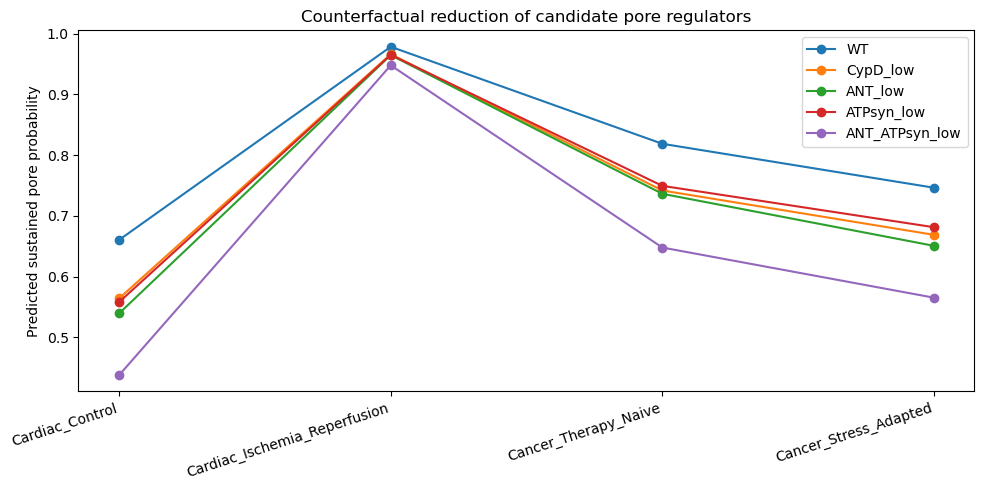

perturbation,WT,CypD_low,ANT_low,ATPsyn_low,ANT_ATPsyn_low
state,,,,,
Cardiac_Control,0.660703,0.564480,0.539801,0.558441,0.438271
Cardiac_Ischemia_Reperfusion,0.978334,0.966151,0.964643,0.965052,0.947807
Cancer_Therapy_Naive,0.818717,0.741870,0.736464,0.749508,0.648032
Cancer_Stress_Adapted,0.746440,0.668959,0.650858,0.681476,0.565562


In [25]:

counterfactual = (
    df.groupby(["state","perturbation"])["sustained_pore_prob"]
    .mean().reset_index()
    .pivot(index="state", columns="perturbation", values="sustained_pore_prob")
    .reindex(index=state_order, columns=pert_order)
)
counterfactual.to_csv(OUTDIR / "counterfactual_intervention_summary.csv")

fig, ax = plt.subplots(figsize=(10,5))
for pert in pert_order:
    ax.plot(counterfactual.index, counterfactual[pert], marker="o", label=pert)
ax.set_title("Counterfactual reduction of candidate pore regulators")
ax.set_ylabel("Predicted sustained pore probability")
plt.xticks(rotation=18, ha="right")
ax.legend(frameon=True)
plt.tight_layout()
fig.savefig(OUTDIR / "15_counterfactual_interventions.png", dpi=220, bbox_inches="tight")
plt.show()

display(counterfactual)


## 6. Final note

This synthetic notebook supports the following experimentally testable ideas:

- **Cardiac ischemia-reperfusion** is the most pore-permissive and injury-prone state.
- **Cancer stress adaptation** preserves viability despite persistent mitochondrial stress by shifting the threshold for catastrophic opening.
- **ANT**, **Cyclophilin D**, and **ATP synthase-linked mechanisms** behave as a **cooperative system**.
- A reconstitution centered on **ANT + ATP synthase + Cyclophilin D**, optionally with **PiC**, is the most defensible current biochemical proof-of-concept system for experimental follow-up.
